In [2]:
# Cell 1: Fix paths and reload modules
import sys
import os

# Get the correct path (go up one level from notebooks to project root)
project_root = os.path.dirname(os.getcwd())  # This goes from ...\notebooks to ...\NetflixProject
sys.path.append(project_root)

print(f"Project root: {project_root}")
print(f"Current working directory: {os.getcwd()}")

# Check if src folder exists
src_path = os.path.join(project_root, 'src')
if os.path.exists(src_path):
    print(f"✓ Found src folder at: {src_path}")
    print(f"Files in src folder: {os.listdir(src_path)}")
else:
    print(f"✗ src folder not found at: {src_path}")

# Delete the old modules from cache if they exist
modules_to_remove = ['src.recommender', 'src.utils', 'src.data_loader']
for module in modules_to_remove:
    if module in sys.modules:
        del sys.modules[module]

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import fresh
from src.data_loader import DataLoader
from src.recommender import Recommender
from src.utils import Analyzer

print("\n✓ All modules imported successfully!")

Project root: c:\Users\NEHA\Desktop\NetflixProject
Current working directory: c:\Users\NEHA\Desktop\NetflixProject\notebooks
✓ Found src folder at: c:\Users\NEHA\Desktop\NetflixProject\src
Files in src folder: ['data_loader.py', 'recommender.py', 'utils.py', '__init__.py', '__pycache__']

✓ All modules imported successfully!


In [3]:
# Load and preprocess data
# Initialize data loader
data_loader = DataLoader(data_path='../data/netflix_dataset.csv')

# Load data (creates sample if file doesn't exist)
df = data_loader.load_data()

# Preprocess
df = data_loader.preprocess_data()

print(f"\nFinal dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

No data file found. Creating sample dataset...
Dataset shape: (100000, 5)
Unique users: 2000
Unique movies: 1000

Final dataset shape: (100000, 7)
Columns: ['user_id', 'movie_id', 'rating', 'genre', 'movie_name', 'user_num', 'movie_num']


In [4]:
# Explore the data
print("First 5 rows:")
print(df.head())

print("\nDataset info:")
print(df.info())

print("\nBasic statistics:")
print(df.describe())

First 5 rows:
   user_id  movie_id  rating      genre movie_name  user_num  movie_num
0     2127       860       4    Romance  Movie_860      1126        859
1     2460       724       2     Comedy  Movie_724      1459        723
2     1861       202       1  Adventure  Movie_202       860        201
3     2295       287       4      Drama  Movie_287      1294        286
4     2131       147       5     Comedy  Movie_147      1130        146

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   user_id     100000 non-null  int32
 1   movie_id    100000 non-null  int32
 2   rating      100000 non-null  int64
 3   genre       100000 non-null  str  
 4   movie_name  100000 non-null  str  
 5   user_num    100000 non-null  int16
 6   movie_num   100000 non-null  int16
dtypes: int16(2), int32(2), int64(1), str(2)
memory usage: 3.4 MB
None

Basic sta

In [5]:
# Genre analysis
analyzer = Analyzer(df)
genre_counts, genre_avg = analyzer.genre_analysis()

GENRE ANALYSIS

📊 MOST POPULAR GENRES:
  Drama: 11,699 ratings
  Action: 10,317 ratings
  Comedy: 10,227 ratings
  Documentary: 9,923 ratings
  Adventure: 9,913 ratings
  Animation: 9,889 ratings
  Horror: 9,732 ratings
  Sci-Fi: 9,571 ratings
  Romance: 9,440 ratings
  Thriller: 9,289 ratings

⭐ BEST RATED GENRES:
  Documentary: 3.82 (9,923.0 ratings)
  Drama: 3.82 (11,699.0 ratings)
  Horror: 3.82 (9,732.0 ratings)
  Animation: 3.81 (9,889.0 ratings)
  Sci-Fi: 3.81 (9,571.0 ratings)
  Action: 3.8 (10,317.0 ratings)
  Romance: 3.8 (9,440.0 ratings)
  Comedy: 3.8 (10,227.0 ratings)
  Adventure: 3.79 (9,913.0 ratings)
  Thriller: 3.79 (9,289.0 ratings)

📉 WORST RATED GENRES:
  Thriller: 3.79 (9,289.0 ratings)
  Adventure: 3.79 (9,913.0 ratings)
  Romance: 3.8 (9,440.0 ratings)
  Comedy: 3.8 (10,227.0 ratings)
  Action: 3.8 (10,317.0 ratings)
  Animation: 3.81 (9,889.0 ratings)
  Sci-Fi: 3.81 (9,571.0 ratings)
  Horror: 3.82 (9,732.0 ratings)
  Drama: 3.82 (11,699.0 ratings)
  Documentar

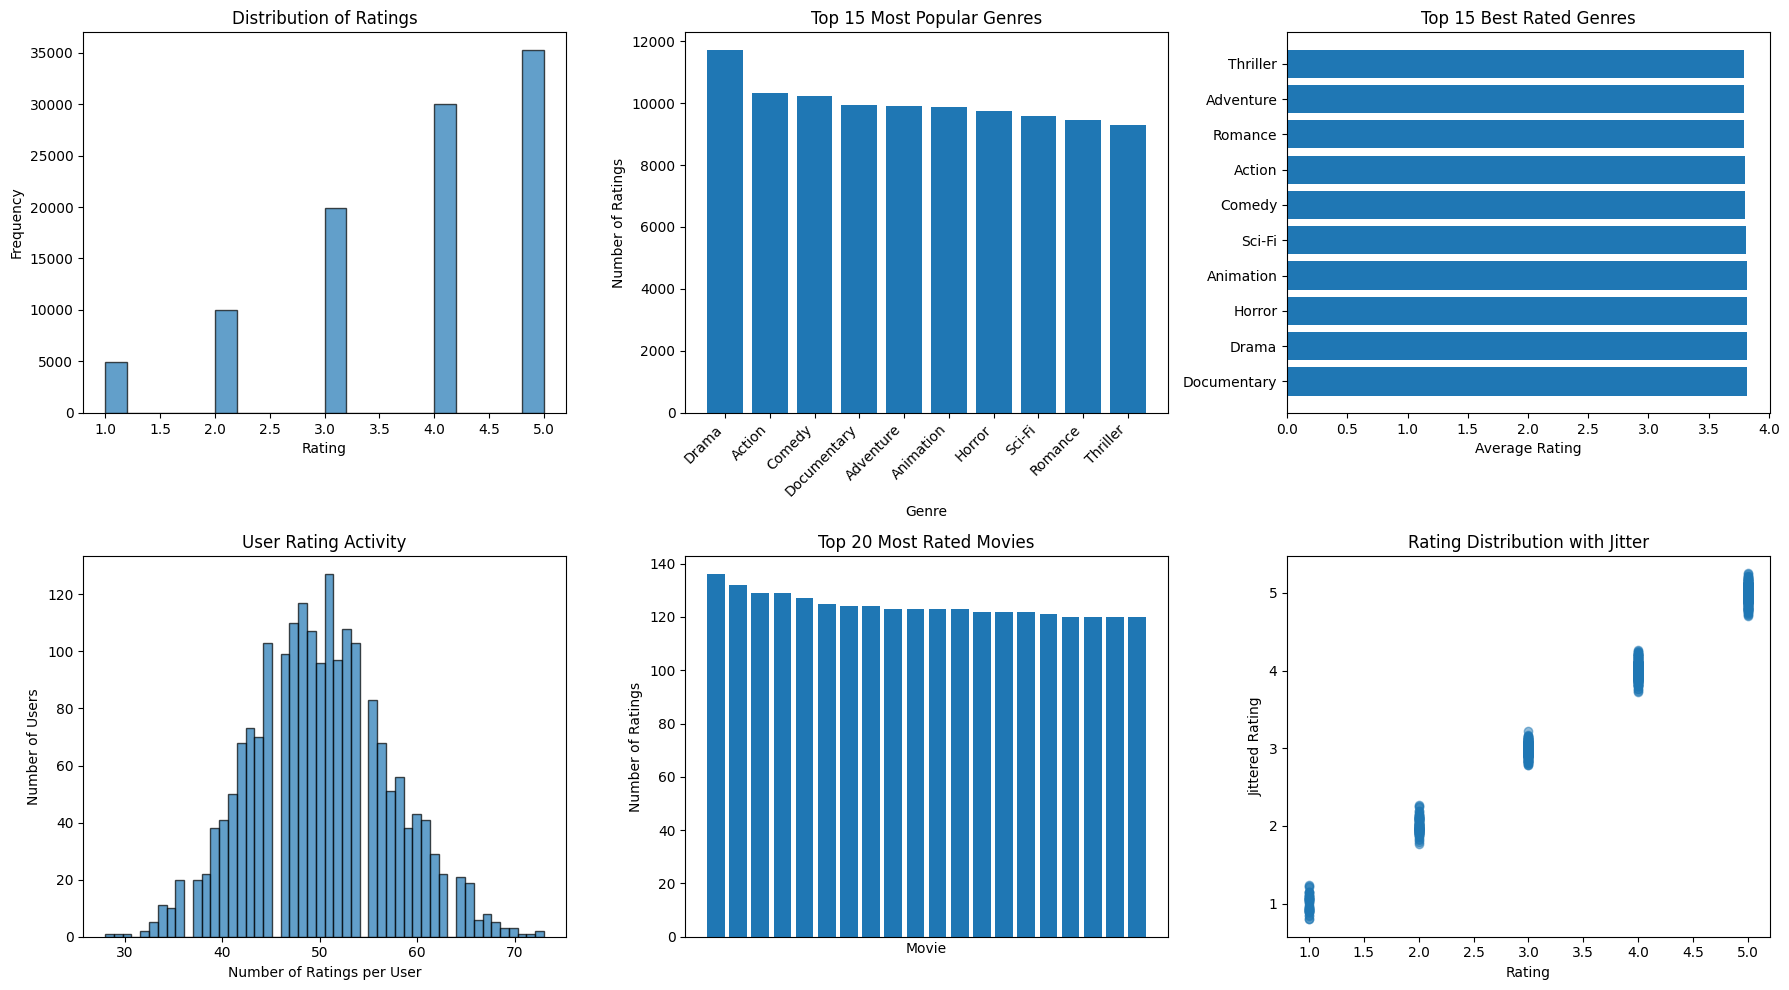

✓ Dashboard saved to ../output/dashboard.png


In [6]:
# Create visualizations
analyzer.plot_dashboard(save_path='../output/dashboard.png')

In [7]:
# Build recommendation system
# Initialize recommender
recommender = Recommender(df)

# Create matrices
recommender.create_matrices()

# Test for a sample user
sample_user = df['user_id'].iloc[0]
print(f"Sample user ID: {sample_user}")

Initializing Recommender...
Creating matrices...
User-movie matrix shape: (2000, 1000)
Sample user ID: 2127


In [8]:
# Try different user IDs
test_users = df['user_id'].unique()[:5]  # First 5 users
for user in test_users:
    print(f"\n🎬 Recommendations for User {user}:")
    recs = recommender.recommend_user_based(user, n_recommendations=5)
    print(recs.to_string(index=False))


🎬 Recommendations for User 2127:
Getting user-based recommendations for user 2127...


Formatting 5 recommendations...
Movie_num: 10, Score: 5.0, Score type: <class 'numpy.float64'>
Movie_num: 45, Score: 5.0, Score type: <class 'numpy.float64'>
Movie_num: 51, Score: 5.0, Score type: <class 'numpy.float64'>
Movie_num: 65, Score: 5.0, Score type: <class 'numpy.float64'>
Movie_num: 77, Score: 5.0, Score type: <class 'numpy.float64'>
   Movie    Genre  Predicted Rating
Movie_11   Horror               5.0
Movie_46   Action               5.0
Movie_52 Thriller               5.0
Movie_66 Thriller               5.0
Movie_78   Comedy               5.0

🎬 Recommendations for User 2460:
Getting user-based recommendations for user 2460...
Formatting 5 recommendations...
Movie_num: 19, Score: 5.0, Score type: <class 'numpy.float64'>
Movie_num: 21, Score: 5.0, Score type: <class 'numpy.float64'>
Movie_num: 31, Score: 5.0, Score type: <class 'numpy.float64'>
Movie_num: 35, Score: 5.0, Score type: <class 'numpy.float64'>
Movie_num: 61, Score: 5.0, Score type: <class 'numpy.float64'>
   M

In [9]:
# Get item-based recommendations
print("="*60)
print(f"ITEM-BASED RECOMMENDATIONS FOR USER {sample_user}")
print("="*60)

item_based_recs = recommender.recommend_item_based(sample_user, n_recommendations=10)
if len(item_based_recs) > 0:
    print(item_based_recs.to_string(index=False))
else:
    print("No recommendations available for this user.")

ITEM-BASED RECOMMENDATIONS FOR USER 2127
Getting item-based recommendations for user 2127...
Formatting 10 recommendations...
Movie_num: 673, Score: 4.604472699178936, Score type: <class 'numpy.float64'>
Movie_num: 928, Score: 4.603569668306081, Score type: <class 'numpy.float64'>
Movie_num: 376, Score: 4.585463940463104, Score type: <class 'numpy.float64'>
Movie_num: 397, Score: 4.556893008423099, Score type: <class 'numpy.float64'>
Movie_num: 768, Score: 4.536903987949824, Score type: <class 'numpy.float64'>
Movie_num: 724, Score: 4.532204392184697, Score type: <class 'numpy.float64'>
Movie_num: 351, Score: 4.527187712425772, Score type: <class 'numpy.float64'>
Movie_num: 341, Score: 4.48973150844622, Score type: <class 'numpy.float64'>
Movie_num: 33, Score: 4.483640807040013, Score type: <class 'numpy.float64'>
Movie_num: 52, Score: 4.4829569410192525, Score type: <class 'numpy.float64'>
    Movie     Genre  Predicted Rating
Movie_674     Drama              4.60
Movie_929     Drama 

In [10]:
# Get popularity-based recommendations (for new users)
print("="*60)
print("POPULARITY-BASED RECOMMENDATIONS")
print("="*60)

popular_recs = recommender.recommend_popular(n_recommendations=10)
print(popular_recs.to_string(index=False))

print("\n" + "="*60)
print("POPULAR ACTION MOVIES")
print("="*60)
action_popular = recommender.recommend_popular(genre='Action', n_recommendations=5)
print(action_popular.to_string(index=False))

POPULARITY-BASED RECOMMENDATIONS
Getting popular recommendations... Genre: None
Movie stats shape: (1000, 5)
Rating count type: int64
Avg rating type: float64
Movie: Movie_701, Score: 4.223000000000001, Type: <class 'float'>
Movie: Movie_932, Score: 4.215794117647059, Type: <class 'float'>
Movie: Movie_990, Score: 4.157882352941177, Type: <class 'float'>
Movie: Movie_538, Score: 4.139647058823529, Type: <class 'float'>
Movie: Movie_123, Score: 4.122676470588234, Type: <class 'float'>
Movie: Movie_23, Score: 4.090647058823529, Type: <class 'float'>
Movie: Movie_591, Score: 4.082588235294118, Type: <class 'float'>
Movie: Movie_133, Score: 4.080470588235294, Type: <class 'float'>
Movie: Movie_197, Score: 4.076441176470589, Type: <class 'float'>
Movie: Movie_30, Score: 4.074529411764706, Type: <class 'float'>
Formatting 10 recommendations...
Movie_num: 700, Score: 4.223000000000001, Score type: <class 'float'>
Movie_num: 931, Score: 4.215794117647059, Score type: <class 'float'>
Movie_num:

In [11]:
# Find best movie in each genre for a user
print("="*60)
print(f"BEST MOVIE IN EACH GENRE FOR USER {sample_user}")
print("="*60)

top_genres = df['genre'].value_counts().head(5).index

for genre in top_genres:
    # Get movies in this genre not rated by user
    user_num = df[df['user_id'] == sample_user]['user_num'].iloc[0]
    genre_movies = df[df['genre'] == genre]
    user_rated = df[df['user_num'] == user_num]['movie_num'].tolist()
    
    unrated = genre_movies[~genre_movies['movie_num'].isin(user_rated)]
    
    if len(unrated) > 0:
        # Simple approach: highest rated
        best = unrated.loc[unrated['rating'].idxmax()]
        print(f"  {genre}: {best['movie_name']} (Rating: {best['rating']})")

BEST MOVIE IN EACH GENRE FOR USER 2127
  Drama: Movie_290 (Rating: 5)
  Action: Movie_384 (Rating: 5)
  Comedy: Movie_147 (Rating: 5)
  Documentary: Movie_934 (Rating: 5)
  Adventure: Movie_639 (Rating: 5)


In [12]:
# Generate recommendations for multiple users
print("="*60)
print("GENERATING RECOMMENDATIONS FOR SAMPLE USERS")
print("="*60)

sample_users = df['user_id'].unique()[:20]
all_recommendations = []

for i, user_id in enumerate(sample_users, 1):
    try:
        recs = recommender.recommend_user_based(user_id, n_recommendations=5)
        recs['User_ID'] = user_id
        all_recommendations.append(recs)
        print(f"✓ Generated recommendations for user {i}/20")
    except Exception as e:
        print(f"✗ Error for user {user_id}: {e}")

if all_recommendations:
    final_recs = pd.concat(all_recommendations, ignore_index=True)
    
    # Save to CSV
    output_path = '../output/recommendations.csv'
    final_recs.to_csv(output_path, index=False)
    print(f"\n✓ Saved {len(final_recs)} recommendations to {output_path}")
    
    print("\nSample recommendations:")
    print(final_recs.head(10).to_string(index=False))

GENERATING RECOMMENDATIONS FOR SAMPLE USERS
Getting user-based recommendations for user 2127...


Formatting 5 recommendations...
Movie_num: 10, Score: 5.0, Score type: <class 'numpy.float64'>
Movie_num: 45, Score: 5.0, Score type: <class 'numpy.float64'>
Movie_num: 51, Score: 5.0, Score type: <class 'numpy.float64'>
Movie_num: 65, Score: 5.0, Score type: <class 'numpy.float64'>
Movie_num: 77, Score: 5.0, Score type: <class 'numpy.float64'>
✓ Generated recommendations for user 1/20
Getting user-based recommendations for user 2460...
Formatting 5 recommendations...
Movie_num: 19, Score: 5.0, Score type: <class 'numpy.float64'>
Movie_num: 21, Score: 5.0, Score type: <class 'numpy.float64'>
Movie_num: 31, Score: 5.0, Score type: <class 'numpy.float64'>
Movie_num: 35, Score: 5.0, Score type: <class 'numpy.float64'>
Movie_num: 61, Score: 5.0, Score type: <class 'numpy.float64'>
✓ Generated recommendations for user 2/20
Getting user-based recommendations for user 1861...
Formatting 5 recommendations...
Movie_num: 576, Score: 5.000000000000001, Score type: <class 'numpy.float64'>
Movie_nu

In [13]:
# Project summary
print("="*70)
print("🎬 NETFLIX RECOMMENDATION ENGINE - PROJECT SUMMARY")
print("="*70)

print("\n📊 DATASET STATISTICS:")
print(f"  • Total Ratings: {len(df):,}")
print(f"  • Unique Users: {df['user_id'].nunique():,}")
print(f"  • Unique Movies: {df['movie_id'].nunique():,}")
print(f"  • Unique Genres: {df['genre'].nunique():,}")

print("\n🎯 ANSWERS TO PROJECT QUESTIONS:")
print(f"  1. Most Popular Genre: {genre_counts.index[0]} ({genre_counts.values[0]:,} ratings)")
print(f"  2. Best Rated Genre: {genre_avg.index[0]} (⭐ {genre_avg.iloc[0]['mean']:.2f})")
print(f"  3. Worst Rated Genre: {genre_avg.sort_values('mean').index[0]} (📉 {genre_avg.sort_values('mean').iloc[0]['mean']:.2f})")

print("\n🤖 RECOMMENDATION ENGINE SPECS:")
print(f"  • Algorithms: User-based CF, Item-based CF, Popularity-based")
print(f"  • Matrix Shape: {recommender.user_movie_matrix.shape}")
print(f"  • Users Covered: {recommender.user_movie_matrix.shape[0]}")
print(f"  • Movies Covered: {recommender.user_movie_matrix.shape[1]}")

print("\n📁 OUTPUT FILES CREATED:")
print("  • output/dashboard.png - Data visualizations")
print("  • output/recommendations.csv - Personalized recommendations")

print("\n" + "="*70)
print("✅ PROJECT COMPLETED SUCCESSFULLY!")
print("="*70)

🎬 NETFLIX RECOMMENDATION ENGINE - PROJECT SUMMARY

📊 DATASET STATISTICS:
  • Total Ratings: 100,000
  • Unique Users: 2,000
  • Unique Movies: 1,000
  • Unique Genres: 10

🎯 ANSWERS TO PROJECT QUESTIONS:
  1. Most Popular Genre: Drama (11,699 ratings)
  2. Best Rated Genre: Documentary (⭐ 3.82)
  3. Worst Rated Genre: Thriller (📉 3.79)

🤖 RECOMMENDATION ENGINE SPECS:
  • Algorithms: User-based CF, Item-based CF, Popularity-based
  • Matrix Shape: (2000, 1000)
  • Users Covered: 2000
  • Movies Covered: 1000

📁 OUTPUT FILES CREATED:
  • output/dashboard.png - Data visualizations
  • output/recommendations.csv - Personalized recommendations

✅ PROJECT COMPLETED SUCCESSFULLY!


In [15]:
import pickle
import os

# Create output folder if it doesn't exist
os.makedirs('output', exist_ok=True)

# Save the recommender model
with open('output/recommender_model.pkl', 'wb') as f:
    pickle.dump(recommender, f)
    
print("✅ Model saved to output/recommender_model.pkl")
print(f"File size: {os.path.getsize('output/recommender_model.pkl') / 1024 / 1024:.2f} MB")

✅ Model saved to output/recommender_model.pkl
File size: 56.99 MB
